In [5]:
import pandas as pd
# Load the full dataset with appropriate encoding

df = pd.read_csv(r"C:\Users\HP\Downloads\archive\AviationData.csv", encoding='latin1')
df

C:\Users\HP\AppData\Local\Temp\ipykernel_23660\2546409625.py:4: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\HP\Downloads\archive\AviationData.csv", encoding='latin1')


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88884,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
88885,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88886,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
88887,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [8]:
df.head


<bound method NDFrame.head of              Event.Id Investigation.Type Accident.Number  Event.Date  \
0      20001218X45444           Accident      SEA87LA080  1948-10-24   
1      20001218X45447           Accident      LAX94LA336  1962-07-19   
2      20061025X01555           Accident      NYC07LA005  1974-08-30   
3      20001218X45448           Accident      LAX96LA321  1977-06-19   
4      20041105X01764           Accident      CHI79FA064  1979-08-02   
...               ...                ...             ...         ...   
88884  20221227106491           Accident      ERA23LA093  2022-12-26   
88885  20221227106494           Accident      ERA23LA095  2022-12-26   
88886  20221227106497           Accident      WPR23LA075  2022-12-26   
88887  20221227106498           Accident      WPR23LA076  2022-12-26   
88888  20221230106513           Accident      ERA23LA097  2022-12-29   

              Location        Country   Latitude  Longitude Airport.Code  \
0      MOOSE CREEK, ID  Unite

In [10]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [12]:
# Define the columns we want to keep
columns_to_keep = [
    'Event.Date',
    'Make',
    'Model',
    'Injury.Severity',
    'Aircraft.damage',
    'Aircraft.Category',
    'Purpose.of.flight',
    'Total.Fatal.Injuries',
    'Total.Serious.Injuries'
]

# Filter the dataset
df_cleaned = df[columns_to_keep].copy()

# Convert Event.Date to datetime format
df_cleaned['Event.Date'] = pd.to_datetime(df_cleaned['Event.Date'], errors='coerce')

# Convert injuries to numeric (some may be read as strings or contain NaNs)
df_cleaned['Total.Fatal.Injuries'] = pd.to_numeric(df_cleaned['Total.Fatal.Injuries'], errors='coerce').fillna(0)
df_cleaned['Total.Serious.Injuries'] = pd.to_numeric(df_cleaned['Total.Serious.Injuries'], errors='coerce').fillna(0)

# Drop rows missing essential info
df_cleaned = df_cleaned.dropna(subset=['Make', 'Model', 'Event.Date'])

# Optional: reset index
df_cleaned.reset_index(drop=True, inplace=True)

# Show the cleaned dataset
df_cleaned.head()

,Event.Date,Make,Model,Injury.Severity,Aircraft.damage,Aircraft.Category,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries
0,1948-10-24,Stinson,108-3,Fatal(2),Destroyed,NaN,Personal,2.0,0.0
1,1962-07-19,Piper,PA24-180,Fatal(4),Destroyed,NaN,Personal,4.0,0.0
2,1974-08-30,Cessna,172M,Fatal(3),Destroyed,NaN,Personal,3.0,0.0
3,1977-06-19,Rockwell,112,Fatal(2),Destroyed,NaN,Personal,2.0,0.0
4,1979-08-02,Cessna,501,Fatal(1),Destroyed,NaN,Personal,1.0,2.0


In [25]:
df_cleaned.to_csv("C:/Users/HP/Downloads/cleaned_aviation_data.csv", index=False)


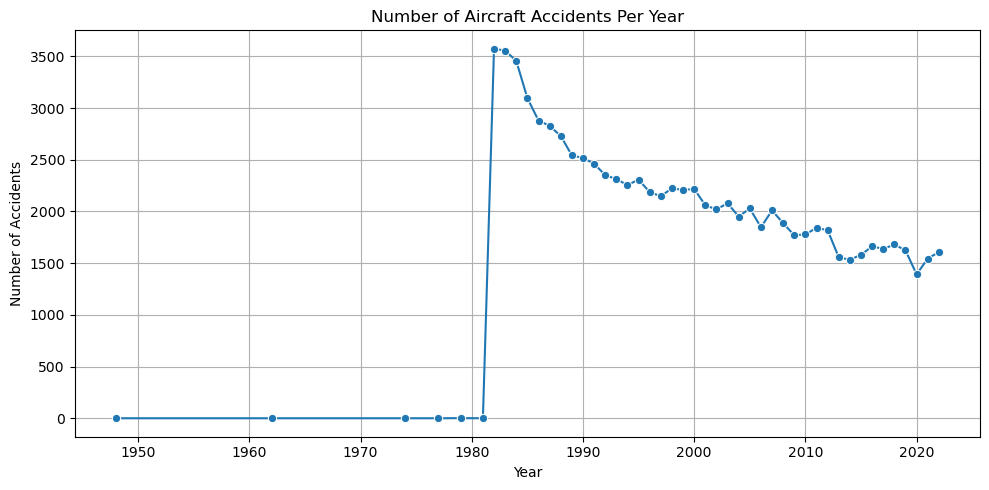

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year
df_cleaned['Year'] = df_cleaned['Event.Date'].dt.year
accidents_per_year = df_cleaned.groupby('Year')['Event.Date'].count().reset_index(name='Num_Accidents')

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=accidents_per_year, x='Year', y='Num_Accidents', marker='o')
plt.title('Number of Aircraft Accidents Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.tight_layout()
plt.show()

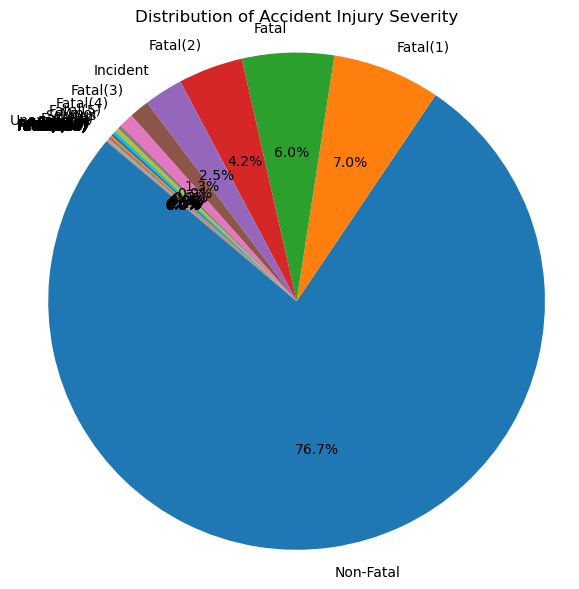

In [21]:
# Count Injury Severity
severity_counts = df_cleaned['Injury.Severity'].value_counts().reset_index()
severity_counts.columns = ['Injury Severity', 'Count']

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(severity_counts['Count'], labels=severity_counts['Injury Severity'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Accident Injury Severity')
plt.axis('equal')
plt.tight_layout()
plt.show()
